In [245]:
import pandas as pd

In [246]:
train_df = pd.read_csv('archive/customer_churn_dataset-training-master.csv')
test_df = pd.read_csv('archive/customer_churn_dataset-testing-master.csv')

In [247]:
train_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [248]:
train_df.shape

(440833, 12)

In [249]:
train_df['Subscription Type'].value_counts()

Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64

In [250]:
train_df['Contract Length'].value_counts()

Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64

In [251]:
train_df.drop(['CustomerID'], axis=1, inplace=True)
X = train_df.drop('Churn', axis=1)
y = train_df['Churn']

In [252]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                440832 non-null  float64
 1   Gender             440832 non-null  str    
 2   Tenure             440832 non-null  float64
 3   Usage Frequency    440832 non-null  float64
 4   Support Calls      440832 non-null  float64
 5   Payment Delay      440832 non-null  float64
 6   Subscription Type  440832 non-null  str    
 7   Contract Length    440832 non-null  str    
 8   Total Spend        440832 non-null  float64
 9   Last Interaction   440832 non-null  float64
dtypes: float64(7), str(3)
memory usage: 33.6 MB


In [253]:
y.value_counts()

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64

In [254]:
X = pd.get_dummies(X, columns=["Contract Length","Subscription Type","Gender"])
# X['Gender'] = X['Gender'].map({'Male': 0, 'Female': 1})
# X['Subscription Type'] = X['Subscription Type'].map({'Basic': 0, 'Standard': 1, 'Premium': 2})
# X['Contract Length'] = X['Contract Length'].map({'Monthly': 0, 'Quarterly': 1, 'Annual': 2})

In [255]:
X.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Contract Length_Annual,Contract Length_Monthly,Contract Length_Quarterly,Subscription Type_Basic,Subscription Type_Premium,Subscription Type_Standard,Gender_Female,Gender_Male
0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,True,False,False,False,False,True,True,False
1,65.0,49.0,1.0,10.0,8.0,557.0,6.0,False,True,False,True,False,False,True,False
2,55.0,14.0,4.0,6.0,18.0,185.0,3.0,False,False,True,True,False,False,True,False
3,58.0,38.0,21.0,7.0,7.0,396.0,29.0,False,True,False,False,False,True,False,True
4,23.0,32.0,20.0,5.0,8.0,617.0,20.0,False,True,False,True,False,False,False,True


In [256]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

In [257]:
import numpy as np

mask = ~np.isnan(X_scaled).any(axis=1)
X_scaled = X_scaled[mask]
y = y[mask]

In [258]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.utils.data
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [ ]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

# train validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# convert to tensors
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train.values).float().view(-1,1)

X_val = torch.from_numpy(X_val).float()
y_val = torch.from_numpy(y_val.values).float().view(-1,1)

# simple neural network
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid()
)

# loss and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
train_losses = []
# training loop
epochs = 20

for epoch in range(epochs):

    # forward
    preds = model(X_train)

    # loss
    loss = loss_fn(preds, y_train)

    # backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    print(f"Epoch {epoch} Loss: {loss.item():.4f}")

# validation accuracy
with torch.no_grad():
    preds = model(X_val)
    preds = (preds > 0.95).float()
    acc = (preds == y_val).float().mean()

print("Validation Accuracy:", acc.item())

Epoch 0 Loss: 0.6952
Epoch 1 Loss: 0.6901
Epoch 2 Loss: 0.6852
Epoch 3 Loss: 0.6784
Epoch 4 Loss: 0.6682
Epoch 5 Loss: 0.6548
Epoch 6 Loss: 0.6385
Epoch 7 Loss: 0.6201
Epoch 8 Loss: 0.6005
Epoch 9 Loss: 0.5808
Epoch 10 Loss: 0.5623
Epoch 11 Loss: 0.5462
Epoch 12 Loss: 0.5340
Epoch 13 Loss: 0.5259
Epoch 14 Loss: 0.5211
Epoch 15 Loss: 0.5181
Epoch 16 Loss: 0.5163
Epoch 17 Loss: 0.5151
Epoch 18 Loss: 0.5140
Epoch 19 Loss: 0.5130
Validation Accuracy: 0.9023103713989258


In [260]:
# copy test data
test_proc = test_df.copy()

# encode categorical variables
test_proc = pd.get_dummies(test_proc, columns=["Contract Length","Subscription Type","Gender"])

# drop non-feature columns
if "CustomerID" in test_proc.columns:
    test_proc = test_proc.drop(columns=["CustomerID"])

if "Churn" in test_proc.columns:
    y_test = test_proc["Churn"]
    test_proc = test_proc.drop(columns=["Churn"])

test_proc = test_proc.reindex(columns=X.columns, fill_value=0)

# scale features
X_test_scaled = sc.transform(test_proc)

# convert to tensor
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

# predict
model.eval()
with torch.no_grad():
    probs = model(X_test_t)

# convert probability → class
preds = (probs > 0.95).float()

# show predictions
print(preds[:10])

tensor([[1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.]])


In [261]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, preds.numpy())
print("Test Accuracy:", acc)

Test Accuracy: 0.5943237953210924


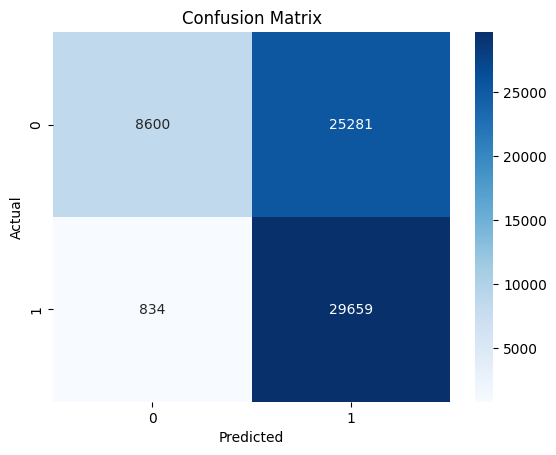

In [262]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, preds.numpy())

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

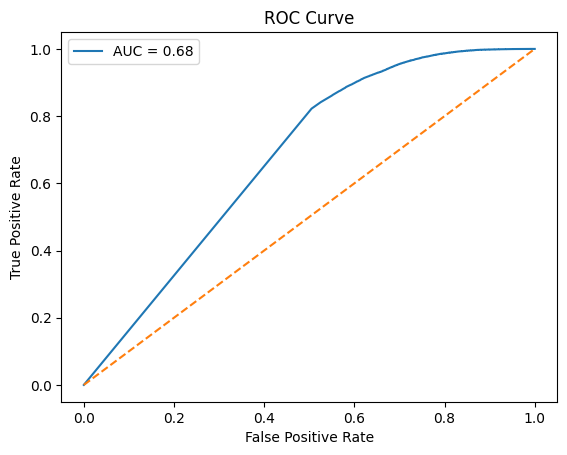

In [263]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

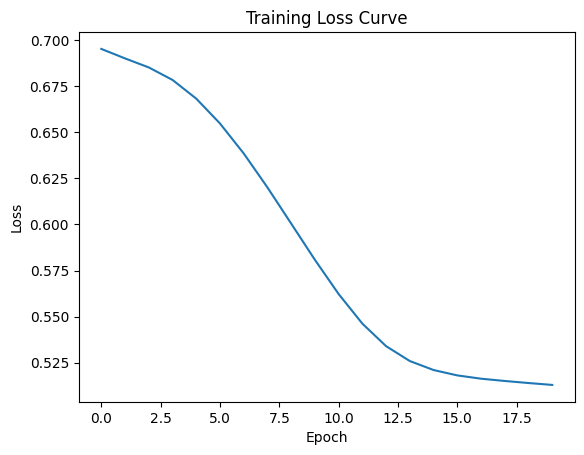

In [264]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [265]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds.numpy()))

              precision    recall  f1-score   support

           0       0.91      0.25      0.40     33881
           1       0.54      0.97      0.69     30493

    accuracy                           0.59     64374
   macro avg       0.73      0.61      0.55     64374
weighted avg       0.74      0.59      0.54     64374

